# Array Basics

## ndarray attributes

- `.shape` : return a tuple
- `.ndim`
- `.size` : total number of elements
- `.dtype`

In [ ]:
import numpy as np  # Importing the NumPy module
a = np.arange(1, 4, 1)  # Creating an array of integers from 12 to 30 with step 3
print(a)
print(a.shape, 'is a\' dim b/c a is a vector that row or column orientation doesn\'t matter')
print(a.ndim)
print(a.size) # the same size as b
print(a.dtype)

b=np.array([[1],[2],[3]])
print(b.ndim, 'is b\'s dim')
print(b.shape, 'is b\'s shape b/c b is a vector')
print(b.size, 'n * m')

c = np.arange(1, 4, 1).reshape(1,3) 
print(c)
print(c.shape, 'is c\' dim b/c a is a vector that row or column orientation doesn\'t matter')
print(c.ndim)
print(c.size) # the same size as c
print(c.dtype)
print(c.shape[1])# number of columns)

[1 2 3]
(3,) is a' dim b/c a is a vector that row or column orientation doesn't matter
1
3
int64
2 is b's dim
(3, 1) is b's shape b/c b is a vector
3 n * m
[[1 2 3]]
(1, 3) is c' dim b/c a is a vector that row or column orientation doesn't matter
2
3
int64
3


### comparison: Array, ndarray, Pd.series, Pd.DataFrame

- `[]`
    - access index of list, string, tuple and the key of dict
    - ndarray: access the index of 
    - pd.series: `.iloc[]` int index;  `.loc[]` same as `[]` for label
    - pd.dataframe: `.iloc[]` int index;  `.loc[]` for label; `[]` for column label
- `*` `+`
    - with same dimension expanding list, string, and tuple
    - ndarray: with same dimension/broadcasting, add or multiply
    - pd.series and pd.dataframe: addition and multiplication aligns labels
- `nan` (ndarray and Pandas both use `np.nan` dtype)
    - ndarray: `sum` `nan` returns `nan`
    - pd.series and pd.dataframe: `mean`, `sum`, etc. ignores `nan`.

#### `[]`

In [ ]:
import pandas as pd
a=pd.Series(data=[1, 2 , 1.2, 10], index=[1, 2, 3, 4]) # index is called the label!
print(a.iloc[1]) # for int index 
print(a.loc[1])  # for label
print(a[1])      # for label

2.0
1.0
1.0


#### `+ *`

In [44]:
x=[1, 2 , 1.2, 10]
print(x+x)
y=np.array([1,2,1.2,10])
print(y+np.array([1]))
b=pd.Series(data=[1, 2 , 1.2, 10], index=[0, 1, 0, 2])
print(a+b)


[1, 2, 1.2, 10, 1, 2, 1.2, 10]
[ 2.   3.   2.2 11. ]
0     NaN
0     NaN
1     3.0
2    12.0
3     NaN
4     NaN
dtype: float64


In [ ]:
# how to fill NaN for either series/dataframe before operation
# 1: uses fill_values for binary operation add, sub, mul, div, floordiv, mod, pow
print(a.add(b, fill_value=1))
a2=a+b
# 2: use fillna(), ffill(), bfill(), replace()
print(a2.fillna(0))
print(a2.ffill().bfill())
print(a2.replace(np.nan,0))
# 3: fillering and replace
a2[np.isnan(a2)]=0
print(a2)


0     2.0
0     2.2
1     3.0
2    12.0
3     2.2
4    11.0
dtype: float64
0     0.0
0     0.0
1     3.0
2    12.0
3     0.0
4     0.0
dtype: float64
0     3.0
0     3.0
1     3.0
2    12.0
3    12.0
4    12.0
dtype: float64
0     0.0
0     0.0
1     3.0
2    12.0
3     0.0
4     0.0
dtype: float64
0     0.0
0     0.0
1     3.0
2    12.0
3     0.0
4     0.0
dtype: float64


> how to add series with misaligned labels?

>> Note: `.replace(old, new)` or `str.replace(old,new)` and using `np.nan` `np.isnan` for `NaN`.

In [70]:
a=pd.Series(data=[1, 2 , 1.2, 10], index=[1, 2, 3, 4]) # index is called the label!
b=pd.Series(data=[1, 2 , 1.2, 10], index=[0, 1, 0, 2])
# 1: to_numpy
print(pd.Series(a.to_numpy()+b.to_numpy()))
# 2: reset index
# 2.1: use reset_index
print(a.reset_index(drop=True)+b.reset_index(drop=True)) 
        # reset_index() create a new column called index that is the index of the series and then return a DataFrame
        # reset_index(drop=True) reset index as 0, 1, ...
# 2.2: use reindex
a=pd.Series(data=[1, 2 , 1.2, 10], index=[1, 2, 3, 4]) # index is called the label!
b=pd.Series(data=[1, 2 , 1.2, 10], index=[0, 1, 0, 2])
print(a.reindex(b.index)) # uses b's index 
print(a.reindex(b.index)+b) # sum series and uses b's label

0     2.0
1     4.0
2     2.4
3    20.0
dtype: float64
0     2.0
1     4.0
2     2.4
3    20.0
dtype: float64
0    NaN
1    1.0
0    NaN
2    2.0
dtype: float64
0     NaN
1     3.0
0     NaN
2    12.0
dtype: float64


#### `nan`

- Numpy: use `np.nan_to_num(<a>, nan=#)`
- both Numpy and Pandas use `a[np.isnan(a)]=0`

In [81]:
m = np.array([1, np.nan, 3])
np.sum(m)          # nan
# 1: use na modifed math
np.nansum(m)       # 4.0  (special NaN-aware version)
# 2: replace using np.nan_to_num
print(np.sum(np.nan_to_num(m, nan=0)))  # 4.0
# 2: replace using np.isnan
m[np.isnan(m)]=0
print(np.sum(m))

# compare with pd.series
s = pd.Series([1, np.nan, 3])
s.sum()+2            # 4.0  (skips NaN by default)

4.0
4.0


np.float64(6.0)

## create array from a list

In [3]:
a = np.arange(6)  # Creating an array of integers from 0 to 5
b = np.array([1, 2, 3, 4, 5, 6])  # Creating an array of integers from 1 to 6
c = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])  # Creating a 2-D (two-dimensional) array of shape (3, 4)

print(a)
print(b)
print(c)
print(type(c))


[0 1 2 3 4 5]
[1 2 3 4 5 6]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
<class 'numpy.ndarray'>


> a shape of (n, ) represents a sequence that does not distinguish between row or column orientation

In [8]:
# create array
def create_array(x,y):
    return [[i for i in range(y)] for i in range(x)]
print(np.array(create_array(2,3)).shape)
print(np.array(create_array(2,3)))

(2, 3)
[[0 1 2]
 [0 1 2]]


>    list comprehension to create rows
    ```
    [i for i in range(y)]
    ```

## create array with known size but unknown contents

In [93]:
a = np.zeros((3, 4))
b = np.ones((2, 3), dtype=np.bool)
c = np.empty((2, 3)) # randomly allocate contents
print(type(a))

<class 'numpy.ndarray'>


In [ ]:
# returning a tuple if multiple items returned
def test():
    return 1, 2

print(type(test()))
print(test()[0])

<class 'tuple'>
1


## create array from arange(start, stop, step)
> Note: excluding the `stop` point!

In [92]:
a = np.arange(10, 14, 2)
print(a) # range: 10, 10+1, ...
a = np.arange(10, 14, 1)
print(a) # range: 10, 10+1, ...
a = np.linspace(10.5, 14.5, 2) #
print(a)

[10 12]
[10 11 12 13]
[10.5 14.5]


In [10]:
# function with optional argument
def array_from_range(x=0, y=10, step=None):
    return np.arange(x, y , step)

print(array_from_range()) # use default values; step is optional

print(array_from_range(step=2))

[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]


## linspace

Due to finite floating point precision, it is generally not possible to predict the number of elements obtained when ```arange(start, stop, step)``` is used with floating point arguments. Therefore, in most cases, it is better to use the function ```linspace(start, stop, num)```, which receives as an argument the number of elements we want to get rather than the step:

In [91]:
a = np.linspace(0.0, 2.0, 9)    # 9 numbers from 0 to 2
print(a)

import pandas as pd

# Data provided as a dictionary
data = {
    "City": ["Tokyo", "Delhi", "Shanghai", "Sao Paulo", "Mumbai"],
    "Country": ["Japan", "India", "China", "Brazil", "India"],
    "Population_Millions": [37, 32, 28, 22, 21]
}

# Load the data into a DataFrame object
# note: Numpy assignment is positional and create new column out of Numpy array
df = pd.DataFrame(data, index=['a', 'b','c','d','e'])
df['temp']=np.linspace(0,2, df.shape[0])
print(df['temp'])

df2=pd.Series(np.linspace(0,2, df.shape[0]))
df['tem2']=df2
print(df['tem2'])

[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.  ]
a    0.0
b    0.5
c    1.0
d    1.5
e    2.0
Name: temp, dtype: float64
a   NaN
b   NaN
c   NaN
d   NaN
e   NaN
Name: tem2, dtype: float64


## read & write files

In [ ]:
# read or save files
# files without missing values
# arr = np.loadtxt('my_data.csv', delimiter=',', skiprows=1)

# files with missing values
#arr = np.genfromtxt('my_data.csv', delimiter=',', skip_header=1)

# np.savetxt('test.out', x, delimiter=',')


## reshaping

In [ ]:
a = np.arange(6)
print(np.reshape(a, (2, 3)))

a = np.array([[1, 2, 3], [4, 5, 6]])
print(np.reshape(a, 6).shape) # Reshape a 2D array into a 1D array:

a = np.array([[1, 2, 3], [4, 5, 6]])
print(a.flatten())

[[0 1 2]
 [3 4 5]]
(6,)
[1 2 3 4 5 6]


## random sampling
`Generator` is a container that exposes a number of methods for generating random numbers drawn from a variety of probability distributions. Call `default_rng` to get a new instance of Generator, then call its methods to obtain samples from different distributions.

In [94]:
# uniform distribution
rng=np.random.default_rng(seed=2026)
rng.uniform(1,2, size=3)

array([1.17893481, 1.63991317, 1.4672684 ])

0.008306721807359696
0.021054001939868616


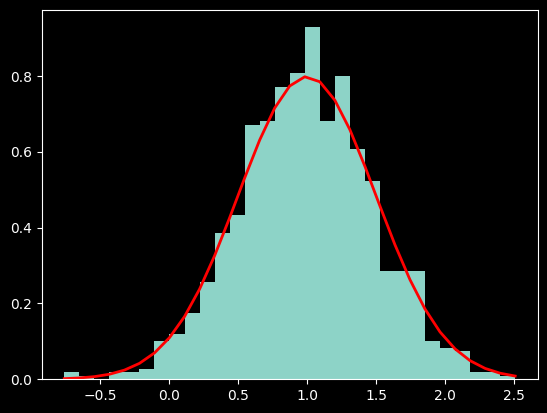

In [ ]:
# normal distribution
rng = np.random.default_rng()

mu, sigma = (1,0.5) # Mean and standard deviation
s = rng.normal(mu,sigma,1000)

import matplotlib.pyplot as plt

print(abs(mu - np.mean(s)))  # Difference should be close to 0.0
print(abs(sigma - np.std(s, ddof=1)))  # Difference should be close to 0.0

count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1 / (sigma * np.sqrt(2 * np.pi)) *
         np.exp(- (bins - mu) ** 2 / (2 * sigma ** 2)),
         linewidth=2, color='r')
plt.show()

## random shuffle

In [97]:
rng = np.random.default_rng()
arr = np.arange(100).reshape(5, 20)
rng.shuffle(arr,axis=0) # shuffle rows keeping element within rows the same
a=arr.flatten()
fully_random = rng.permutation(a,axis=0)
print(fully_random)

[26 53 84 25 86 96 54  8 97 92 39 77  3 50 36 37 48 80 16 57 81 51 74 70
 20  4 30 29 89 32 22 19 44 42 34 62 91 33 79 93  5 47  1 69 78  6 67 40
 35 76 43 10 85 45 72 64 52 11 15 38 82  2 98 56 68 24 75 94 41 55 90 18
 13 83  9 60 73 49 28 21 17 87 65 59  7 99 71 46 61 88 23 58 14 63 66  0
 31 95 12 27]


## broadcasting

In [14]:
v = np.array([1, 0, 1])
# stacking array together
vv = np.tile(v, (4, 1))
print(vv)
x = np.arange(10)
k=x.reshape(10,1) # reshape does not modify the matrix in place
print(k.shape)

y = np.ones(7)
print(y)
print(k+y)

[[1 0 1]
 [1 0 1]
 [1 0 1]
 [1 0 1]]
(10, 1)
[1. 1. 1. 1. 1. 1. 1.]
[[ 1.  1.  1.  1.  1.  1.  1.]
 [ 2.  2.  2.  2.  2.  2.  2.]
 [ 3.  3.  3.  3.  3.  3.  3.]
 [ 4.  4.  4.  4.  4.  4.  4.]
 [ 5.  5.  5.  5.  5.  5.  5.]
 [ 6.  6.  6.  6.  6.  6.  6.]
 [ 7.  7.  7.  7.  7.  7.  7.]
 [ 8.  8.  8.  8.  8.  8.  8.]
 [ 9.  9.  9.  9.  9.  9.  9.]
 [10. 10. 10. 10. 10. 10. 10.]]


In [ ]:
data = [0.16666667, 0.01754386, 0.05263158,0.13157895, 0.16666667,0.13157895, 0.14035088, 0.01754386, 0.12280702, 0.05263158]

data = np.array(data)
print(-np.sum(data*np.log2(data)))

2.1159167885653076


# Array indexing and slicing

## indexing basics

using square brackets

In [ ]:
# 1D array indexing the same as the base
x=np.arange(5)
print(x)
print(x[2:], 'print index 2 to end')
print(x[3], 'print index 3')
print(x[:3], 'print up to index 3')
print(x[0:4:2],'print start index 0 until 4 (exclusive)')

[0 1 2 3 4]
[2 3 4] print index 2 to end
3 print index 3
[0 1 2] print up to index 3
[0 2] print start index 0 until 4


In [28]:
# 2-d array
x = np.arange(10).reshape(2, 5) # 2-dimensional
print(x)
print(x[1, 3])
print(x[1, -1])
print(x[0], 'works because', x[0][0], 'is identical to', x[0,0])
print(x[1],'print row indexed 1')

# iterate over rows
for row in x:
    print(row)

# iterate over rows and print index values
for index, row in enumerate(x):
    print(f'row is {row}, and index is {index}')

# iterate over columns
for column in x.T:
    print(column)


[[0 1 2 3 4]
 [5 6 7 8 9]]
8
9
[0 1 2 3 4] works because 0 is identical to 0
[5 6 7 8 9] print row indexed 1
[0 1 2 3 4]
[5 6 7 8 9]
row is [0 1 2 3 4], and index is 0
row is [5 6 7 8 9], and index is 1
[0 5]
[1 6]
[2 7]
[3 8]
[4 9]


## slicing

> trick 1: using fancy index to preserve dimension

> trick 2: use ```reshape(-1,1)``` to convery 1D to 2D array

> trick 3: reshaping by adding a new axis
> * a[:, None] == a[:, np.newaxis]
> * a[None, :] == a[np.newaxis, :]


In [24]:
x = np.arange(35)
y = x.reshape(5, 7)
print(y)
print(y[1:5:2], 'selects rows by indies 1:5:2')
print(y[:,1:5:2],'selects columns')
print(y[1:5:2, ::2], 'First slicing in the first dimension, then in the second.')  #
print(y[:,:-1], 'select all rows and exclude last column')
print(y[:,-1], 'select last column')
print(y[:,-1].ndim, 'select last column as 1D array')
print(y[-1,:].shape, 'check again Python reduces dimensionality')
print(y[-1,0:3].reshape(-1,1), 'auto matically determines nrows')
print(y[[-1],:].shape,'fancy indexing preserves the dimensionality')

[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34]]
[[ 7  8  9 10 11 12 13]
 [21 22 23 24 25 26 27]] selects rows by indies 1:5:2
[[ 1  3]
 [ 8 10]
 [15 17]
 [22 24]
 [29 31]] selects columns
[[ 7  9 11 13]
 [21 23 25 27]] First slicing in the first dimension, then in the second.
[[ 0  1  2  3  4  5]
 [ 7  8  9 10 11 12]
 [14 15 16 17 18 19]
 [21 22 23 24 25 26]
 [28 29 30 31 32 33]] select all rows and exclude last column
[ 6 13 20 27 34] select last column
1 select last column as 1D array
(7,) check again Python reduces dimensionality
[[28]
 [29]
 [30]] auto matically determines nrows
(1, 7) fancy indexing preserves the dimensionality


## integer array indexing

In [ ]:
x = np.arange(15).reshape(5, 3)
print(x)
print('---------------')
print(x[np.array([0, 1,4])],'selects rows with indices')
y=x[np.array([0, 1, 4]), np.array([0, 0, 1])]
print(y, 'selects elements', y.shape, 'loses the domentionality', '\n to add dimentions',y[np.newaxis,:].shape)
print('---------------')

try:
    z=x[np.array([0, 1, 4]), np.array([0, 0])]
except Exception as e:
    print(f'dim is not match--> Python attempts broadcasting--> fails here,the error is{e}')
    print(x[np.array([0, 1, 4]), np.array([0])],'is allowed under broadcasting, but losing dimensionality')

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]
---------------
[[ 0  1  2]
 [ 3  4  5]
 [12 13 14]] selects rows with indices
[ 0  3 13] selects elements (3,) loses the domentionality 
 to add dimentions (1, 3)
---------------
dim is not match--> Python attempts broadcasting--> fails here,the error isshape mismatch: indexing arrays could not be broadcast together with shapes (3,) (2,) 
[ 0  3 12] is allowed under broadcasting


## boolean indexing

case 1: boolean array of the same dim as the original array. The boolean array is called mask. Mask filtering returns a 1D array.

case 2: boolean array has lower dimension but the lower dimension is consistent with the original array; then the dim consistent with the original array selected by the boolean is returned

In [ ]:
# case 1
y = np.arange(20).reshape(5, 4)
b = y % 2 != 0
print(b)
print(y[b])

[[False  True False  True]
 [False  True False  True]
 [False  True False  True]
 [False  True False  True]
 [False  True False  True]]
[ 1  3  5  7  9 11 13 15 17 19]


In [ ]:
print(b[1, :])
print(y[:, b[1, :]]) # selects all row but columns from b

[False  True False  True]
[[ 1  3]
 [ 5  7]
 [ 9 11]
 [13 15]
 [17 19]]


> Note: ```reshape(z<number of blocks>, row, column)```
>    * first dimension: z
>    * second dimension: row (vertical)
>    * third dimension: column (horizontal)

In [ ]:
a = np.arange(20).reshape(2,2,5)
mask = np.array([[True, False],[False, True]])
c = a[mask]

print('Array a:\n', a, '\n')
print('Indexed array c:\n', c)
print(c.shape)


Array a:
 [[[ 0  1  2  3  4]
  [ 5  6  7  8  9]]

 [[10 11 12 13 14]
  [15 16 17 18 19]]] 

Indexed array c:
 [[ 0  1  2  3  4]
 [15 16 17 18 19]]
(2, 5)


### `& | ~` comparison
- Python base: `and` `or` `not`
- Numpy, Pandas: ``& | ~`

But `==` and `!=` common for all.

# Transpose, concatenate

## transpose

In [ ]:
# at the beginner level for 2D array
a = np.arange(15).reshape(3, 5)
print(a.T==a.transpose(1,0))

# A 1D array is a row of a matrix. If we have to transpose it, we must convert this 1D matrix to a 2D matrix and then transpose it.
a = np.array([0, 10, 20, 30, 40])
#b = np.array([[0, 10, 20, 30, 40]])  or use reshape
b = a.reshape(1, 5)
print(a.size)
print(a)
print(b)
print(a.shape)
print(b.shape)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]]
5
[ 0 10 20 30 40]
[[ 0 10 20 30 40]]
(5,)
(1, 5)


In [40]:
# 3D matrix transpose
c0 = np.arange(12).reshape(3,2,2)
print(c0, 'is c0')
print(c0.shape)
c0[0,:,:] # select page 0


[[[ 0  1]
  [ 2  3]]

 [[ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]]] is c0
(3, 2, 2)


array([[0, 1],
       [2, 3]])

> Because A[i(page), j(row), k(column)] works like:
> * i chooses which 2D matrix (page/slice)
> * j chooses row inside that matrix
> * k chooses col inside that matrix

In [42]:
print(c0.transpose(1,2,0).shape, 'is (2,2,3)', c0.transpose(1,2,0)) # new index 0 from old index 1
print(c0.transpose(0,2,1), 'is 0,2,1')
print(c0.transpose(1,0,2), 'is 1,0,2')
print(c0.transpose(0,1,2), 'is 0,1,2')

(2, 2, 3) is (2,2,3) [[[ 0  4  8]
  [ 1  5  9]]

 [[ 2  6 10]
  [ 3  7 11]]]
[[[ 0  2]
  [ 1  3]]

 [[ 4  6]
  [ 5  7]]

 [[ 8 10]
  [ 9 11]]] is 0,2,1
[[[ 0  1]
  [ 4  5]
  [ 8  9]]

 [[ 2  3]
  [ 6  7]
  [10 11]]] is 1,0,2
[[[ 0  1]
  [ 2  3]]

 [[ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]]] is 0,1,2


In [43]:
a = np.array([[1, 4], [3, 1]])
a.sort(axis=1)      # Sorts in-place along the second axis. Equivalent to `a.sort()`
print(a)
a.sort(axis=0)      # Sorts in-place along the first axis
print(a)

[[1 4]
 [1 3]]
[[1 3]
 [1 4]]


## concatenate

- `axis=k`: create addition element for kth dimension

In [ ]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([[0, 0, 0]])
print(np.concatenate((a, b), axis=0), 'creates additional rows')
print(np.concatenate((a, b.T), axis=1), "creates columns")
print(np.concatenate((a, b), axis=None), 'a and b are flattened before stacking')

[[1 2 3]
 [4 5 6]
 [7 8 9]
 [0 0 0]] creates additional rows
[[1 2 3 0]
 [4 5 6 0]
 [7 8 9 0]] creates columns
[1 2 3 4 5 6 7 8 9 0 0 0] a and b are flattened before stacking


## stack

joining a sequence along a new axis

Think the number pad on my Ipad. Piling the new array at the back of the Ipad and rotate the Ipad so the axis is at the left facing downwards.

In [ ]:
a = np.array([[1, 2], [3, 4]])
print(np.stack((a, a), axis=0))
print(np.stack((a, a), axis=-1))

[[[1 2]
  [3 4]]

 [[1 2]
  [3 4]]]
[[[1 1]
  [2 2]]

 [[3 3]
  [4 4]]]


In [ ]:
a, b = np.array((1, 2, 3)), np.array((4, 5, 6))
print(np.hstack((a, b)))
c, d = np.array([[1], [2], [3]]), np.array([[4], [5], [6]])
print(np.hstack((c, d)))

[1 2 3 4 5 6]
[[1 4]
 [2 5]
 [3 6]]


In [44]:
a, b = np.array((1, 2, 3)), np.array((4, 5, 6))
print(np.vstack((a, b)))
c, d = np.array([[1], [2], [3]]), np.array([[4], [5], [6]])
print(np.vstack((c, d)))

[[1 2 3]
 [4 5 6]]
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]


| Function | What it does (intuition) | Axis meaning | Input shapes (typical) | Output shape (2D example) | Common use |
|---|---|---|---|---|---|
| `np.concatenate(seq, axis=...)` | Joins arrays along an **existing axis** (no new dimension). | `axis=0` adds rows; `axis=1` adds cols (for 2D). | All arrays must match in shape **except** along `axis`. | If `A,B` are `(m,n)`: `axis=0 -> (m+m, n)`; `axis=1 -> (m, n+n)` | General-purpose “glue” along an existing dimension. |
| `np.stack(seq, axis=...)` | Joins arrays by creating a **new axis** (adds a dimension). | `axis` is the position of the new axis. | All arrays must have **exactly the same shape**. | If `A,B` are `(m,n)`: `axis=0 -> (2, m, n)`; `axis=1 -> (m, 2, n)`; `axis=2 -> (m, n, 2)` | Make “pages”/channels; combine multiple same-shaped arrays into one higher-D array. |
| `np.vstack(seq)` | “Vertical stack” = rows on top of each other. Equivalent to `concatenate(..., axis=0)` for 2D. | Fixed (`axis=0`). | 2D arrays with same #cols; 1D arrays are treated as row vectors `(1,n)` first. | For `(m,n)` + `(k,n)` -> `(m+k, n)` | Quickly append rows / stack observations. |
| `np.hstack(seq)` | “Horizontal stack” = side-by-side columns. For 2D, like `concatenate(..., axis=1)`. | Fixed (behaves like `axis=1` for 2D). | 2D arrays with same #rows; 1D arrays are concatenated into 1D (special case). | For `(m,n)` + `(m,k)` -> `(m, n+k)` | Quickly append columns / stack features. |
| `np.c_[a,b]` | | |


## (opt) split

- `split()` splits an array into multiple sub-arrays of equal size. It accepts an array and the parameter `indices_or_sections`, which is an int or a 1D array. If it is an integer, `N`, the array will be divided into N equal arrays along the axis. If such a split is not possible, an error is raised.
- `array_split` allows the parameter `indices_or_sections` to be an integer that does not divide the axis equally. For an array of length l that should be split into n sections, it returns `l % n` sub-arrays of size `l//n + 1` and the rest of size `l//n`.

In [ ]:
# array_split when the array cannot be evenly divided by the number of sub array
l=4
n=3
x = np.arange(l)
(print(np.array_split(x, n)))
print(f'it returns {l%n} subarrays of size {l//n+1} and the rest of size {l//n}')

[array([0, 1]), array([2]), array([3])]
it returns 1 subarrays of size 2 and the rest of size 1


# compare

## compare with a scalar 
each element compare with a scalar

Boolean is return

In [ ]:
arr = np.arange(10)
filter_ = arr%4==0 # index divisible by 4
print(arr[filter_]) # filter with a mask

[0 4 8]


## elementwise comparison


In [45]:
# can use broadcast for comparison
a = np.arange(20).reshape(4, 5)
b = np.arange(0,30,6).reshape(1,5)
print(np.equal(a,b))


[[ True False False False False]
 [False  True False False False]
 [False False  True False False]
 [False False False  True False]]


In [ ]:
print(np.equal([0, 1, 3], np.arange(3)), 'return an array')
print(np.array_equal([1, 2], [1, 2]),'returns a single T or F')

[ True  True False] return an array
True returns a single T or F


# Numpy Math

Reductions (collapse an axis)
- `np.sum(a, axis=None, keepdims=False)`
- `np.prod(a, axis=None)`
- `np.mean(a, axis=None)`
- `np.std(a, axis=None, ddof=0)`
- `np.var(a, axis=None, ddof=0)`
- `np.median(a, axis=None)`
- `np.any(a, axis=None)`
- `np.all(a, axis=None)`

Cumulative operations
- `np.cumsum(a, axis=None)`
- `np.cumprod(a, axis=None)`

 Linear algebra
- `np.dot(a, b)`                  (dot product / matrix product for 2D)
- `a @ b` / `np.matmul(a, b)`     (matrix multiplication)

Other operations
- `np.linalg.norm(a, ord=None)`
- `np.linalg.solve(A, b)`         (solve Ax=b)
- `np.linalg.inv(A)`              (matrix inverse)
- `np.linalg.eig(A)`

# sort, search

## sort

the k axis I am sorting: I allow contents for this axis to be sorted; for 2-d array, sorting the column axis means the contents in the column for each row can be sorted

In [102]:
a = np.array([[4, 3], [1, 1]])
print(np.sort(a))# Sorts along the last axis by default. Returns a copy!
print(np.sort(a, axis=None))# Sorts the flattened array
print(np.sort(a, axis=0))# Sorts along the first axis (row)
print(np.sort(a, axis=1))# Sorts along the second axis (col)

[[3 4]
 [1 1]]
[1 1 3 4]
[[1 1]
 [4 3]]
[[3 4]
 [1 1]]


> some functions replace in-place:
> *  ```numpy.sort()``` (return sorted array) vs ```numpy.ndarray.sort``` (in-place)
> *  ```random.Generator.permutation```(randomly permutes a sequence or returns a permuted range) vs ```random.Generator.shuffle``(modifies an array or sequence in-place by shuffling its contents.)


## indirect sort `argsort`

 `n` at index i: the ith element of `ndarray` is `ndarray[n]`  

 `numpy.take_along_axis(<input>, <index array>, axix=?)` takes values from the input array using an index array along the axis.

In [106]:
x = np.array([3, 1, 2])
x_sort=np.argsort(x)
print(x_sort)
print(x[x_sort])

[1 2 0]
[1 2 3]


In [107]:
# return the sorted array; position is the index of the previous array
y = np.array([[0, 3], [2, 1]])
ind = np.argsort(y, axis=0)  # Sorts along the first axis (down)
print(ind, '1 at row 1 column 2 means: the second column has 3 and 1. the sorted value should have the index 1 ')
print(np.take_along_axis(y, ind, axis=0))  # Same as np.sort(x, axis=0)

[[0 1]
 [1 0]] 1 at row 1 column 2 means: the second column has 3 and 1. the sorted value should have the index 1 
[[0 1]
 [2 3]]


## partial sort

`kth` is the 0-based sorted position to partition around. After partitioning, the element at index `kth` is in the same position it would have in a fully sorted array; all elements before it are <= it, and all elements after it are >= it.”

```
import numpy as np
a = np.array([7, 1, 7, 7, 1, 5, 7, 2, 3, 2, 6, 2, 3, 0])
p = np.partition(a, 4)
p
>>>array([0, 1, 2, 1, 2, 5, 2, 3, 3, 6, 7, 7, 7, 7]) # may vary
```
p[4] is 2; all elements in p[:4] are less than or equal to p[4], and all elements in p[5:] are greater than or equal to p[4]. The partition is:
```
[0, 1, 2, 1], [2], [5, 2, 3, 3, 6, 7, 7, 7, 7]
```


In [122]:
a = np.array([1, 0, 2, 2, 17, 5, 6, 13])
b = np.partition(a, 2)
print(a, '\n', b)

[ 1  0  2  2 17  5  6 13] 
 [ 0  1  2  2  5  6 13 17]


In [ ]:
x = np.array([[3, 4],[ 2, 5], [0, 1], [1, 3], [1, 2],[45, 0]])
np.partition(x, kth=5, axis=0)


array([[ 0,  0],
       [ 1,  1],
       [ 1,  2],
       [ 2,  3],
       [ 3,  4],
       [45,  5]])

In [ ]:
# practice
a = np.array([9, 1, 8, 2, 7, 3, 6, 4, 5])
k = 3  # want 3 smallest
p = np.partition(a,kth=2) # !!index starts from 0!!!    
k_small = p[:3]

print("original:", a)
print("partition:", p)
print("k smallest (unsorted):", k_small)
print("k smallest (sorted):", np.sort(k_small))
print("full sort then slice:", np.sort(a)[:3])


original: [9 1 8 2 7 3 6 4 5]
partition: [1 2 3 4 5 6 7 8 9]
k smallest (unsorted): [1 2 3]
k smallest (sorted): [1 2 3]
full sort then slice: [1 2 3]


In [119]:
np.argpartition(x, kth=5, axis=0)

array([[2, 5],
       [3, 2],
       [4, 4],
       [1, 3],
       [0, 0],
       [5, 1]])

In [104]:
x = np.array([[3, 4, 2, 5, 0], [1, 3, 1, 2, 0]])
index_array = np.argpartition(x, kth=2, axis=-1)
print(np.take_along_axis(x, index_array, axis=-1))  # same as np.partition(x, kth=1)

[[0 2 3 4 5]
 [0 1 1 2 3]]


### partial sort exercise

In [126]:
# NumPy partition / argpartition exercises (fill in the blanks)
# Goal: practice partial sorting, top-k, kth element, and per-row top-k
# Rules: DO NOT use np.sort(a) on the full array unless the exercise says so.

# -------------------------
# Exercise 1: k smallest values (NOT necessarily sorted)
# -------------------------
a = np.array([9, 1, 8, 2, 7, 3, 6, 4, 5])
k = 3

# TODO: create p = partially-rearranged version of a so that the first k entries are the k smallest values
p = np.partition(a,k-1)

# TODO: extract the k smallest values from p
k_small = p[:k]

print("a:", a)
print("k smallest (unsorted):", k_small)

# TODO: (optional) sort only these k values (not the full array) and print them
k_small_sorted = np.sort(k_small)
print("k smallest (sorted):", k_small_sorted)

a: [9 1 8 2 7 3 6 4 5]
k smallest (unsorted): [1 2 3]
k smallest (sorted): [1 2 3]


In [ ]:
# -------------------------
# Exercise 2: kth smallest element (order statistic)
# -------------------------
a = np.array([40, 10, 30, 50, 20])

# Here, k is 0-based:
# k=0 -> smallest
# k=1 -> 2nd smallest
# k=2 -> 3rd smallest
k = 2

# TODO: partition so that the element at position indexed k-1 is exactly the kth smallest
p = np.partition(a,kth=k-1)

# TODO: extract the kth smallest value (a scalar)
kth_smallest = p[k-1]

print("\nExercise 2")
print("a:", a)
print("kth smallest:", kth_smallest)

# TODO: verify using a full sort (this is allowed only for verification)
check = np.sort(a)
print("check:", check)


Exercise 2
a: [40 10 30 50 20]
kth smallest: 20
check: [10 20 30 40 50]


In [128]:
# -------------------------
# Exercise 3: median via partition (odd length)
# -------------------------
a = np.array([7, 1, 9, 3, 5, 11, 2])

# TODO: compute the middle index for an odd-length array
mid = len(a)//2

# TODO: partition using mid
p = np.partition(a,mid)

# TODO: median is the element at p[mid] for odd length
median_via_partition = p[mid]

print("\nExercise 3")
print("a:", a)
print("median via partition:", median_via_partition)

# TODO: verify using np.median
print("np.median:", np.median(a))


Exercise 3
a: [ 7  1  9  3  5 11  2]
median via partition: 5
np.median: 5.0


In [131]:
# -------------------------
# Exercise 4: k largest values (NOT necessarily sorted)
# -------------------------
a = np.array([9, 1, 8, 2, 7, 3, 6, 4, 5])
k = 4

# TODO: compute the index that splits off the largest k values
# Hint: it's related to len(a) - k
split = len(a)-k # index 8, 7, 6 , 5

# TODO: partition around that split so the last k entries are the k largest values
p = np.partition(a,split)

# TODO: extract the k largest values from p
k_largest = p[-k:]

print("\nExercise 4")
print("a:", a)
print("k largest (unsorted):", k_largest)

# TODO: sort only the k values if you want them ordered
k_largest_sorted = np.sort(k_largest)
print("k largest (sorted):", k_largest_sorted)


Exercise 4
a: [9 1 8 2 7 3 6 4 5]
k largest (unsorted): [6 7 8 9]
k largest (sorted): [6 7 8 9]


In [132]:
# -------------------------
# Exercise 5: top-k indices using argpartition
# -------------------------
a = np.array([0.1, 0.7, 0.4, 0.9, 0.2])
k = 2

# TODO: find indices of the k largest elements (order doesn't matter yet)
# Hint: use argpartition with a split at len(a) - k
ix = np.argpartition(a,kth=len(a)-k)[-k:]

# TODO: extract the corresponding values
top_vals =a[ix]

print("\nExercise 5")
print("a:", a)
print("top-k indices (unordered):", ix)
print("top-k values (unordered):", top_vals)

# TODO: order those k indices by their values (small->large or large->small, your choice)
# Hint: use argsort on the subset a[ix]
ix_ordered = ix_ordered = ix[np.argsort(a[ix])]

print("top-k indices (ordered):", ix_ordered)
print("top-k values (ordered):", a[ix_ordered])


Exercise 5
a: [0.1 0.7 0.4 0.9 0.2]
top-k indices (unordered): [1 3]
top-k values (unordered): [0.7 0.9]
top-k indices (ordered): [1 3]
top-k values (ordered): [0.7 0.9]


## find maxima

In [ ]:
#1
a = np.array([[10, 11, 12], [13, 14, 15]])
print(np.argmax(a,axis=1))
k=np.expand_dims(np.argmax(a, axis=1),axis=1)

print(k)
print(np.take_along_axis(a,k,axis=1))

[2 2]
[[2]
 [2]]
[[12]
 [15]]


## search
```np.nonzero()``` returns indices of non-zero values and ```np.where(cond, x, y)``` if cond then x else y. 

In [ ]:
a = np.array([[0, 10, 4],[ 11, 7, 3]])
print(np.nonzero(a < 5)) # print index pairs a<5 returns boolean
rowix, colix=np.nonzero(a < 5)
print(dict(zip(rowix, colix))) # not working because 0 is overwritten
print(list(zip(rowix, colix)))
print(np.where(a < 5))

(array([0, 0, 1]), array([0, 2, 2]))
{np.int64(0): np.int64(2), np.int64(1): np.int64(2)}
[(np.int64(0), np.int64(0)), (np.int64(0), np.int64(2)), (np.int64(1), np.int64(2))]
(array([0, 0, 1]), array([0, 2, 2]))


In [61]:
a = np.array([[0, 0, 0, 0, 0],[ 5, 6, 7, 8, 9]])
b = a * 10
print(np.where(a < 5, a, b))
print(np.where(a < 5, ['low'], ['high']))

[[ 0  0  0  0  0]
 [50 60 70 80 90]]
[['low' 'low' 'low' 'low' 'low']
 ['high' 'high' 'high' 'high' 'high']]


## (opt) bicount

- create a bin with size 1 for array of integers i>=0.  
- if the max of int is 10, then the array has 10+1 size
- each index corresponds to the count of int at that index value.

In [66]:
a = np.array([1, 1, 1, 2, 3, 7, 7])
print(np.bincount(a))
print(np.argmax(np.bincount(a)), 'is the most frequent appearing value')

[0 3 1 1 0 0 0 2]
1 is the most frequent appearing value


## unique values

return index or count

In [67]:
a = np.array([[1, 2, 6], [4, 2, 3], [4, 2, 3]])
print(np.unique(a))

[1 2 3 4 6]


In [68]:
value, index=np.unique(a, return_index=True)
print(value)
print(index)

[1 2 3 4 6]
[0 1 5 3 2]


In [69]:
value, count=np.unique(a, return_counts=True)
print(value)
print(count)

[1 2 3 4 6]
[1 3 2 2 1]


In [ ]:
# Exercise: Find the most frequent value (mode) and its indices using np.unique
# Instructions:
# 1) Use np.unique to get:
#    - the sorted unique values
#    - the first index of each unique value in the original array
#    - the count of each unique value
# 2) Identify the most frequent value.
# 3) Return:
#    - the most frequent value
#    - its frequency
#    - the first index where it appears (from return_index)
#    - ALL indices where it appears (using a separate step)

import numpy as np

a = np.array([3, 1, 3, 2, 3, 2, 1, 2, 2, 2])

# TODO: use np.unique with the right options
vals, first_idx, counts = np.unique(
    a,
    return_index=True,
    return_counts=True
)

# TODO: find the position (within vals/counts) of the most frequent value
mode_pos = np.argmax(counts)

# TODO: the most frequent value
mode_val = vals[mode_pos]

# TODO: how many times it appears
mode_count = counts[mode_pos]

# TODO: first index where it appears (use first_idx)
mode_first_index = first_idx[mode_pos]

# TODO: ALL indices where it appears in the original array
mode_all_indices = np.where(a==mode_val)

print("a:", a)
print("unique values:", vals)
print("counts:", counts)
print("most frequent value:", mode_val)
print("frequency:", mode_count)
print("first index of that value:", mode_first_index)
print("all indices of that value:", mode_all_indices)

a: [3 1 3 2 3 2 1 2 2 2]
unique values: [1 2 3]
counts: [2 5 3]
most frequent value: 2
frequency: 5
first index of that value: 3
all indices of that value: (array([3, 5, 7, 8, 9]),)
